# Assumption Checking in the Causal AI Scientist
 ### For a Rigorous Causal Analysis Workflow

This notebook demonstrates CAIS's built-in assumption checking utilities for causal inference. These checks are a core part of what makes CAIS a principled tool for causal analysis rather than an estimation black box.

## Why assumption checking matters

Causal inference is fundamentally different from predictive modelling. A regression or classification model can be evaluated on held-out data: if it predicts well, it is good. Causal estimators cannot be evaluated the same way: the true causal effect is never directly observable from data, so there is no ground truth to compare against.

This means **a causal estimate is only as credible as the assumptions that justify it**.
> A DiD estimator with violated parallel trends, an IV estimator with a weak or endogenous instrument, or a propensity-score model with insufficient overlap will each produce a number, but that number will be wrong in a way that cannot be detected from the data alone.


CAIS allows addressing this by systematically checking the assumptions of each causal method, at two distinct stages:

| Stage | Question answered | Examples |
|---|---|---|
| **Pre-modeling** | Is this causal method valid for this data and study design? | Parallel trends, covariate balance, instrument strength, manipulation test |
| **Post-modeling** | Is the fitted model itself well-specified? | Balance after matching/weighting, GPS residual normality, IV overidentification |

- Pre-modeling checks run *before* any estimator is fitted. A failure here means the chosen method may not be appropriate and the analyst should reconsider the design.
- Post-modeling checks run *after* fitting and assess whether the estimation step introduced additional problems: a propensity-score model can be theoretically valid but empirically misspecified; an IV estimator can use valid instruments that are still collectively inconsistent.

Within each stage, checks are further divided by how they operate:

- **Statistical checks**: assumptions that can be partially verified from the data (e.g., covariate balance, instrument strength).
- **LLM-based reasoning**: assumptions that are fundamentally untestable from data alone (e.g., the exclusion restriction, SUTVA, full mediation). For these, CAIS uses an LLM to reason about plausibility based on the study description and domain knowledge.

Together, these checks provide the analyst with explicit, structured evidence for or against each assumption, turning the assumption audit from an implicit expert judgment into a transparent, reproducible step.

> **Note:** LLM-based checks require an API key set in your environment `.env`:
> ```
> OPENAI_API_KEY=sk-your-openai-api-key-here
> ANTHROPIC_API_KEY=your-anthropic-api-key-here
> TOGETHER_API_KEY=your-together-api-key-here
> GEMINI_API_KEY=your-gemini-api-key-here
> DEEPSEEK_API_KEY=your-deepseek-api-key-here
> OPENROUTER_API_KEY=your-openrouter-api-key-here
> ```
> If no LLM is available, those checks return `passed=None` with an explanation.

In [1]:
from cais.config import get_llm_client

try:
    llm = get_llm_client()
    print(f"LLM client ready: {type(llm).__name__}")
except Exception as e:
    llm = None
    print(f"No LLM available — LLM-based checks will return passed=None. ({e})")

LLM client ready: ChatOpenAI


---
## Pre-modeling assumption checks

Pre-modeling checks are run **before** fitting any causal estimator. Their role is to flag potential violations that would invalidate the chosen method entirely; so the analyst can either switch methods, collect additional data, or at minimum acknowledge the limitation explicitly.

Each check returns a standardised `AssumptionResult` object with three fields:
- `passed`: `True`, `False`, or `None` (inconclusive / requires LLM)
- `reasoning`: a human-readable explanation of the verdict
- `details`: raw statistics (SMDs, F-statistics, p-values, …) for auditability

All checks are constructed around an `AssumptionVariables` container, which holds the dataframe and all relevant variable names. This design keeps function signatures clean and makes it easy to run a full suite of checks for a given method with a single registry lookup.

### Stable Unit Treatment Value Assumption (SUTVA)

SUTVA is the most universal assumption in causal inference: it applies to virtually every method in this notebook, regardless of the identification strategy. It has two distinct components:

| Component | What it means | Example violation |
|---|---|---|
| **No interference** | One unit's treatment does not affect another unit's outcome | Vaccination: treating one person reduces infection risk for their neighbours (herd immunity) |
| **Treatment consistency** | There is only one version of the treatment; all treated units receive the same thing | "Job training" that varies widely in duration, content, and quality across sites |

Because both components are untestable from data alone, no dataset can reveal whether spillovers exist or whether the treatment was consistently applied, SUTVA is always checked via LLM reasoning based on the study description.

This makes **description quality critical**: a study described as "units received treatment" gives the LLM no way to assess consistency; a description that specifies the delivery mechanism, the unit of treatment, and the potential for spillovers allows it to reason precisely.

Below we contrast two settings: one where SUTVA is plausible (individual job training, no network effects) and one where it is likely violated (community-level vaccination with documented spillovers).

In [2]:
from cais.models import AssumptionVariables
from cais.methods.pre_model_assumption_utils import check_sutva
import numpy as np
import pandas as pd

np.random.seed(0)
df_sutva = pd.DataFrame({
    "treat": np.random.binomial(1, 0.5, 200),
    "outcome": np.random.normal(0, 1, 200),
})

# --- Case 1: SUTVA plausible ---
vars_sutva_ok = AssumptionVariables(
    df=df_sutva, treatment="treat", outcome="outcome",
    dataset_description=(
        "Individual-level RCT of a job training program. Each participant attends "
        "sessions independently at a dedicated training centre. Participants are "
        "randomly assigned and do not interact with each other. The program content "
        "is standardised across all sites via a fixed curriculum."
    ),
    variables_summary={"treatment": "treat", "outcome": "outcome"},
)

# --- Case 2: SUTVA likely violated ---
vars_sutva_bad = AssumptionVariables(
    df=df_sutva, treatment="treat", outcome="outcome",
    dataset_description=(
        "Community-level vaccination campaign. Villages are assigned to receive "
        "a vaccine (treatment) or not. Vaccine efficacy creates herd immunity: "
        "untreated individuals in high-coverage villages benefit from reduced "
        "infection risk due to their neighbours being vaccinated (spillover). "
        "Additionally, vaccine formulation varied across supply batches."
    ),
    variables_summary={"treatment": "treat", "outcome": "outcome"},
)

result_sutva_ok  = check_sutva(vars_sutva_ok,  llm=llm)
result_sutva_bad = check_sutva(vars_sutva_bad, llm=llm)

print("Case 1 — job training (plausible):")
print(result_sutva_ok)
print()
print("Case 2 — vaccination with spillovers (likely violated):")
print(result_sutva_bad)

Case 1 — job training (plausible):
passed=True reasoning='The study involves an individual-level RCT where participants are randomly assigned to treatment and do not interact with each other, which minimizes the risk of interference between units. Additionally, the program content is standardized across all sites, ensuring that there are no hidden versions of the treatment that could affect the outcomes. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'SUTVA (Stable Unit Treatment Value Assumption)'}

Case 2 — vaccination with spillovers (likely violated):
passed=False reasoning='The assumption of no interference is violated due to the herd immunity effect created by the vaccination campaign, where untreated individuals in high-coverage villages benefit from reduced infection risk because their neighbors are vaccinated. Additionally, the variation in vaccine formulation across su

### Propensity Score Methods (matching, IPW)

Propensity score methods are used when treatment assignment is not randomised but can be explained by observed covariates. They require three core assumptions:

| Assumption | What it means | How it is checked |
|---|---|---|
| **Conditional ignorability** | No unmeasured confounders: all variables that affect both treatment and outcome are observed and included | Standardised mean differences (SMD) on covariates; \|SMD\| < 0.1 is the conventional threshold |
| **Positivity (overlap)** | Every unit has a non-zero probability of receiving each treatment level | Propensity score overlap: the estimated PS distributions of treated and control units must overlap sufficiently |
| **SUTVA** | One unit's treatment does not affect another's outcome; the treatment is consistently defined | LLM reasoning based on study design (cannot be tested statistically) |

A covariate imbalance (`check_cond_ignorability` → `passed=False`) does not mean the method is wrong; it means the propensity score model needs improvement, or additional confounders need to be measured. Surfacing this early avoids presenting a biased estimate as though it were credible.

In [3]:
import numpy as np
import pandas as pd
from cais.models import AssumptionVariables
from cais.methods.pre_model_assumption_utils import check_cond_ignorability, check_sutva, check_positivity
from cais.methods.propensity_score.base import estimate_propensity_scores

In [4]:
np.random.seed(42)
n = 500
age    = np.random.normal(40, 10, n)
income = np.random.normal(50_000, 15_000, n)
# Confounded: older and higher-income individuals more likely to be treated
ps_true = 1 / (1 + np.exp(-(-2 + 0.05 * age + 0.00002 * income)))
treat  = (np.random.uniform(size=n) < ps_true).astype(int)
y      = 2 * treat + 0.05 * age + np.random.normal(0, 1, n)

df_psm = pd.DataFrame({"treat": treat, "outcome": y, "age": age, "income": income})
covariates_psm = ["age", "income"]

vars_psm = AssumptionVariables(
    df=df_psm, treatment="treat", outcome="outcome", covariates=covariates_psm,
    dataset_description=(
        "Observational study of a job training program (n=500). "
        "Treatment is binary (1 = received training). Covariates: age and income. "
        "Older and higher-income individuals are more likely to receive training."
    ),
    variables_summary={"treatment": "treat", "outcome": "outcome", "covariates": covariates_psm},
)

result_cond_ignorability = check_cond_ignorability(vars_psm)
print(result_cond_ignorability)

passed=False reasoning="Randomization check on 2 covariates (|SMD| < 0.1). Imbalanced: ['age', 'income']." details={'smds': {'age': np.float64(0.4889140892814272), 'income': np.float64(0.20524663785836614)}, 'threshold': 0.1, 'imbalanced': {'age': np.float64(0.4889140892814272), 'income': np.float64(0.20524663785836614)}}


In [5]:
ps = estimate_propensity_scores(df_psm, "treat", covariates_psm)

In [6]:
result_positivity = check_positivity(vars_psm, propensity_scores=ps)
print(result_positivity)

passed=True reasoning='Overlap proportion: 0.890 (threshold 0.5). 16 obs (3.2%) outside [0.1, 0.9]. OK.' details={'treated_range': (0.40825645572832153, 0.9729110629770108), 'control_range': (0.4067719414056034, 0.9120513086201276), 'overlap_range': (0.40825645572832153, 0.9120513086201276), 'overlap_proportion': 0.8898781831106196, 'sufficient_overlap': np.True_, 'n_extreme_ps': 16, 'pct_extreme_ps': 0.032}


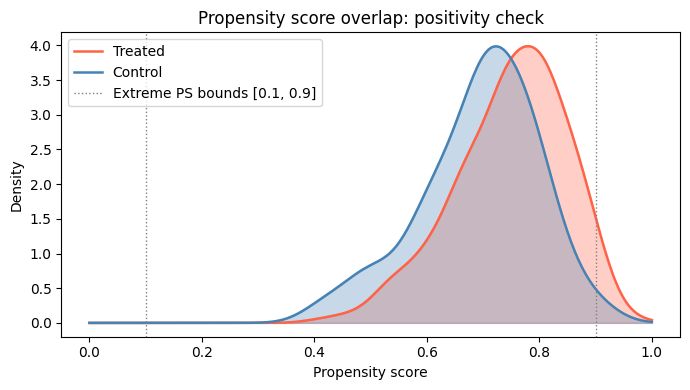

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(7, 4))

for group, label, color in [(1, "Treated", "tomato"), (0, "Control", "steelblue")]:
    scores = ps[df_psm["treat"] == group]
    kde = gaussian_kde(scores)
    x_grid = np.linspace(0, 1, 300)
    ax.fill_between(x_grid, kde(x_grid), alpha=0.3, color=color)
    ax.plot(x_grid, kde(x_grid), color=color, linewidth=1.8, label=label)

ax.axvline(0.1, color="gray", linestyle=":", linewidth=1, label="Extreme PS bounds [0.1, 0.9]")
ax.axvline(0.9, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Propensity score")
ax.set_ylabel("Density")
ax.set_title("Propensity score overlap: positivity check")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
result_sutva = check_sutva(vars_psm, llm=llm)
print(result_sutva)

passed=True reasoning='In the context of the job training program, it is reasonable to assume that the treatment (receiving training) does not interfere with the potential outcomes of other individuals, as the training is likely administered individually and not in a way that affects others. Additionally, there is no indication of hidden versions of the treatment, as the description suggests a binary treatment without variations. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'SUTVA (Stable Unit Treatment Value Assumption)'}


### Instrumental Variables (IVs)

In [9]:
np.random.seed(7)
n_iv = 600
nearc4  = np.random.binomial(1, 0.5, n_iv)
educ    = 10 + 2.5 * nearc4 + np.random.normal(0, 1.5, n_iv)
lwage   = 5.5 + 0.1 * educ + np.random.normal(0, 0.5, n_iv)

df_iv = pd.DataFrame({
    "nearc4": nearc4, "educ": educ, "lwage": lwage,
    "black":   np.random.binomial(1, 0.3, n_iv),
    "smsa":    np.random.binomial(1, 0.6, n_iv),
    "south":   np.random.binomial(1, 0.4, n_iv),
    "married": np.random.binomial(1, 0.5, n_iv),
    "exper":   np.random.randint(1, 25, n_iv).astype(float),
})
iv_covariates = ["black", "smsa", "south", "married", "exper"]

In [10]:
print(f"IV dataset — {df_iv.shape[0]} obs, {df_iv.shape[1]} columns")
df_iv.head()

IV dataset — 600 obs, 8 columns


,nearc4,educ,lwage,black,smsa,south,married,exper
0,0,9.038537,6.864311,0,0,0,0,12.0
1,1,13.522790,6.256203,0,1,0,1,23.0
2,0,12.852892,6.805675,0,1,1,0,17.0
3,1,8.264254,6.088208,0,1,0,1,24.0
4,1,12.034325,6.137407,1,1,1,1,16.0


**Why IV assumptions matter here, and what a valid instrument buys us**

In this dataset, the goal is to estimate the causal effect of **education** (`educ`) on **log wages** (`lwage`). The challenge: education is not randomly assigned; individuals who stay in school longer likely differ on many unobserved characteristics (ability, family background, motivation) that also affect wages. OLS would confound the returns to education with these selection effects.

The instrument **`nearc4`** (grew up near a 4-year college) is proposed as a way around this. The intuition: college proximity reduces the cost of attending, making some individuals more likely to obtain more education; but proximity itself should not directly affect wages.

<div style="text-align:center">
  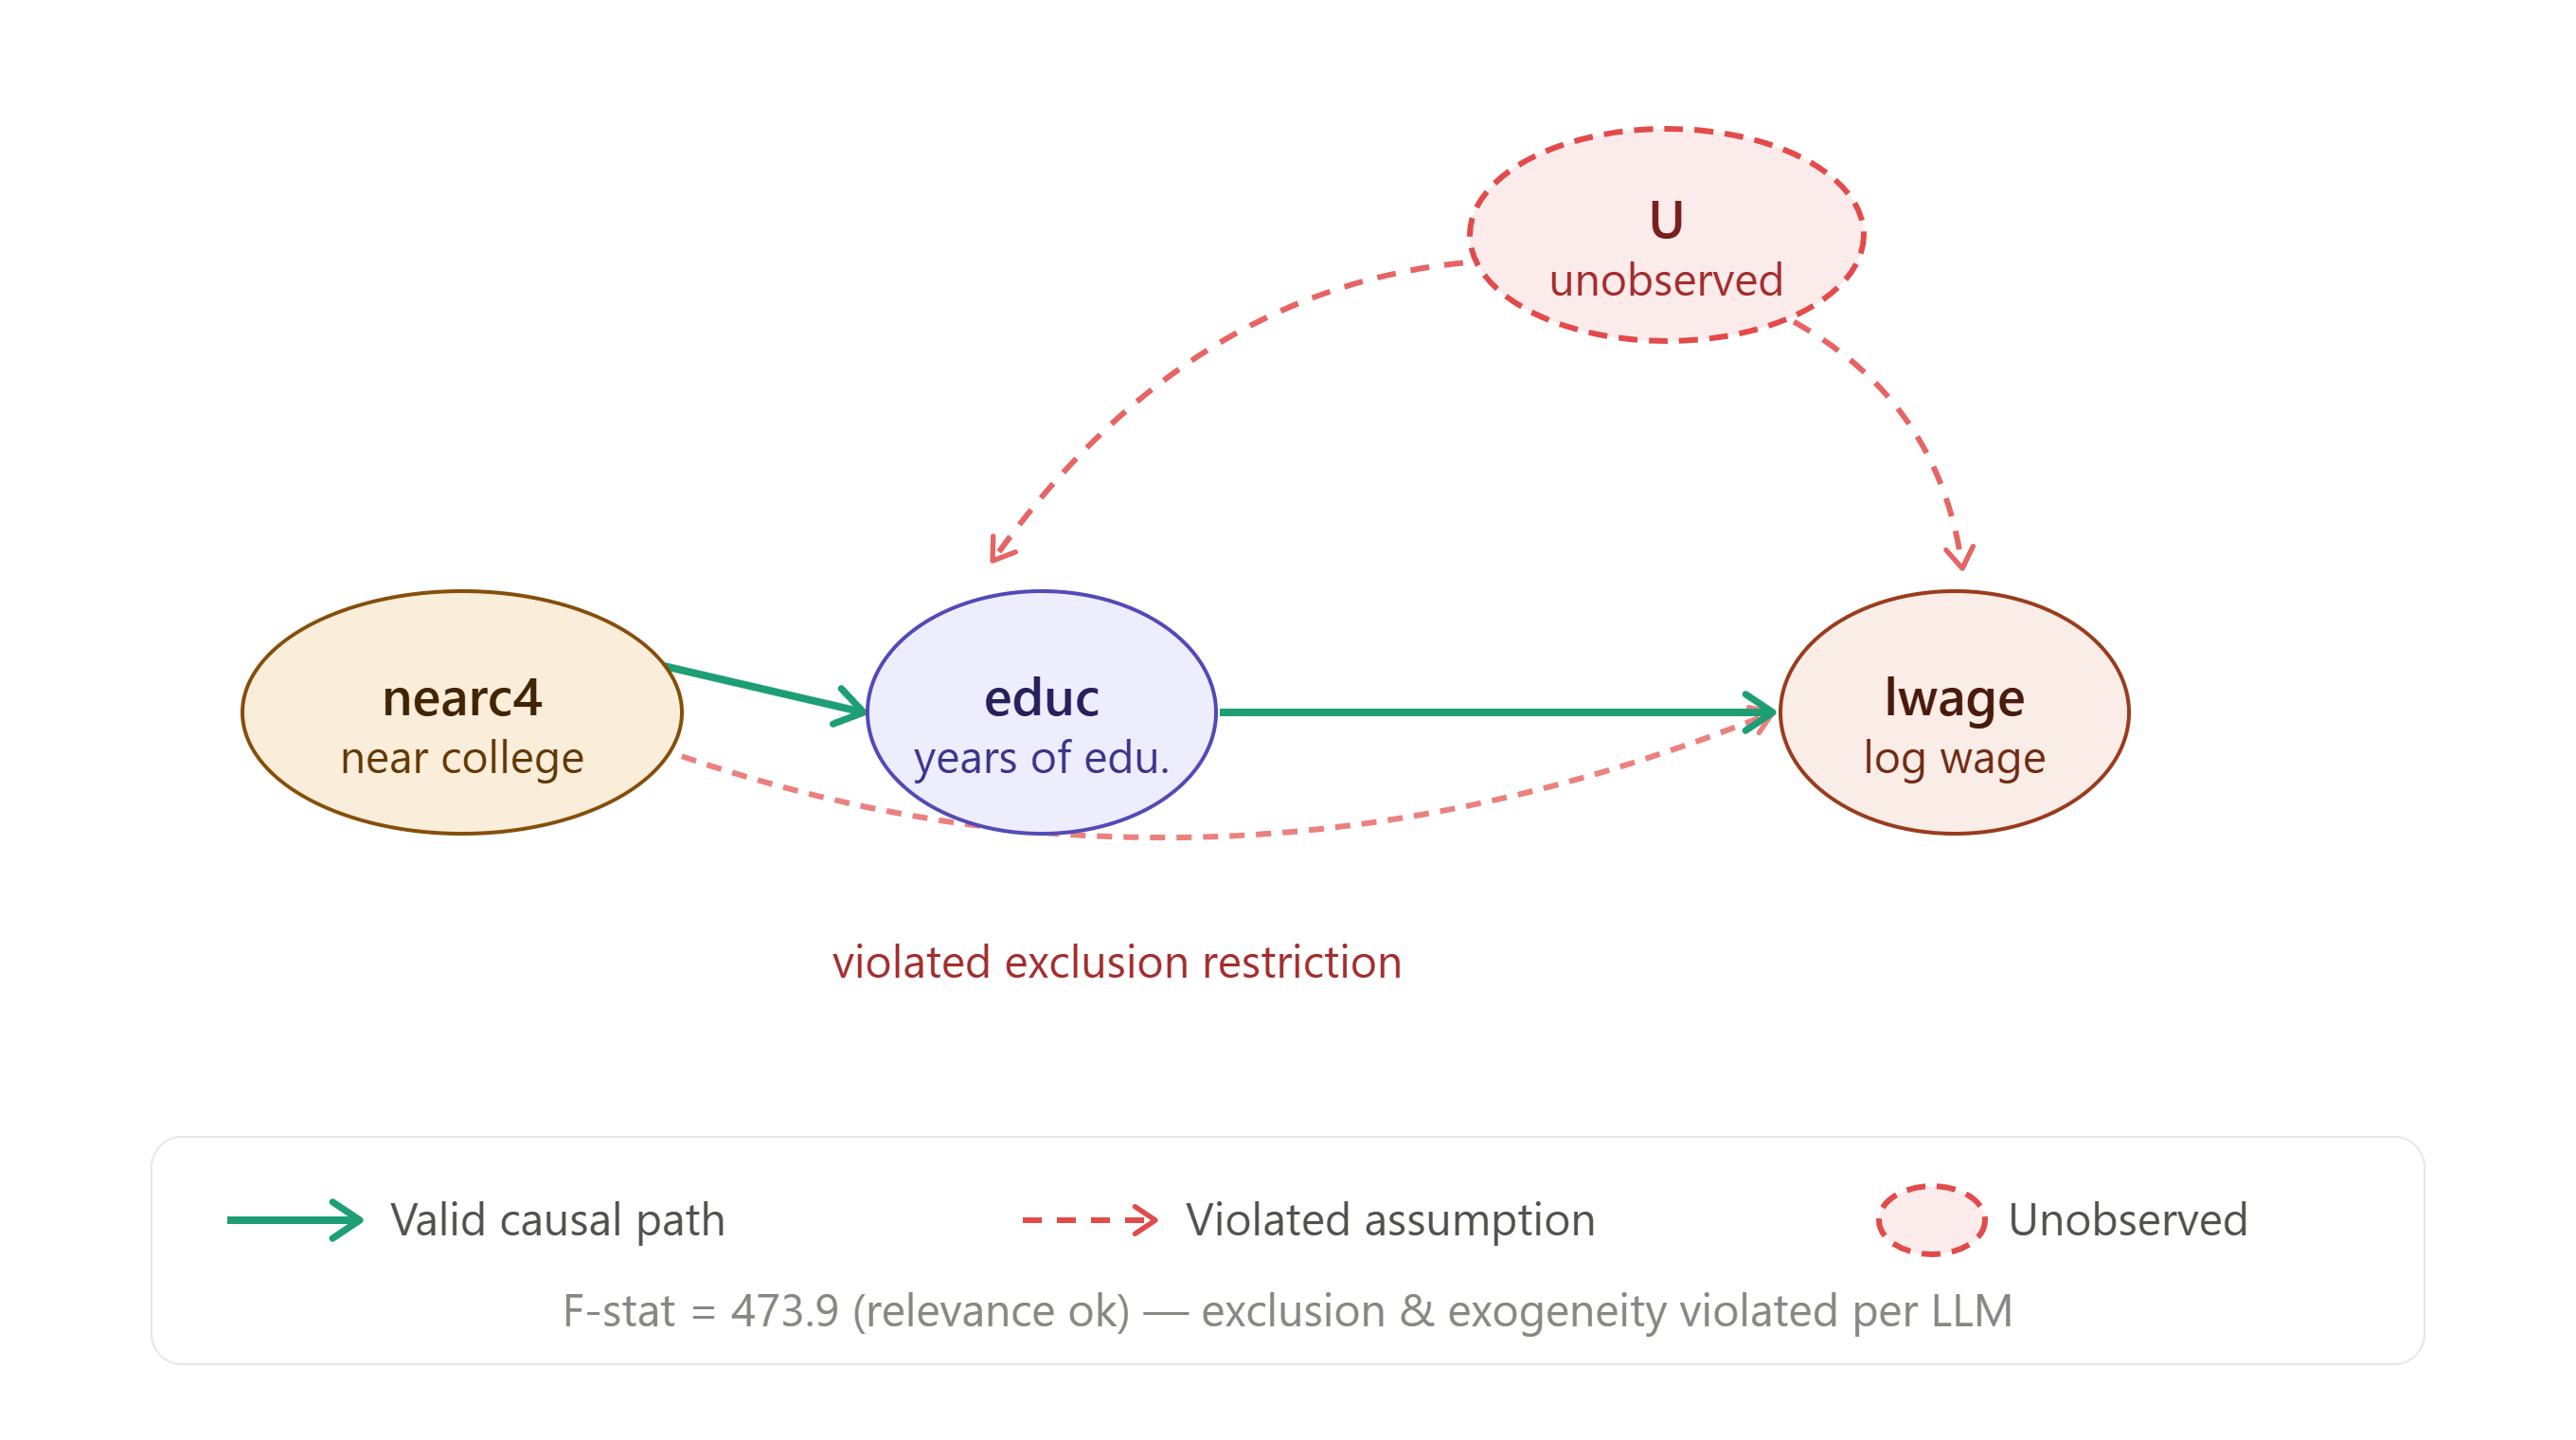
</div>

What each IV assumption means in this context:

| Assumption | Meaning here                                                                                                                                                       |
|---|--------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Relevance** | Growing up near a college actually leads to more years of education, testable via first-stage regression                                                           |
| **Exclusion restriction** | Proximity to a college affects wages *only* through education, not through local labour markets, peer effects, or any other channel                                |
| **Exogeneity** | Where someone grew up is as good as random with respect to unobserved determinants of wages, no selection into college proximity based on family income or ability |
| **Monotonicity** | No one gets *less* education because they grew up near a college, proximity only encourages attendance or has no effect                                            |

If all four assumptions hold, the IV estimator recovers the **LATE** (Local Average Treatment Effect): the causal return to education for individuals whose schooling was actually influenced by college proximity (the "compliers"). This is a credible causal estimate even in the presence of unmeasured confounders between education and wages; something OLS cannot provide.

In [11]:
from cais.methods.pre_model_assumption_utils import (
    check_iv_relevance, check_iv_exclusion, check_iv_exogeneity, check_iv_monotonicity,
)

In [12]:
vars_iv = AssumptionVariables(
    df=df_iv, treatment="educ", outcome="lwage",
    instruments=["nearc4"], covariates=iv_covariates,
)

In [13]:
result_iv_relevance = check_iv_relevance(vars_iv, f_threshold=10.0)
print(result_iv_relevance)

passed=True reasoning='First-stage F = 473.95 (threshold 10.0). Strong instrument.' details={'f_statistic': 473.9459213247547, 'p_value': 1.1403040056337467e-77, 'threshold': 10.0}


F = 473 >> 10: the instrument is strong. Relevance is the **only IV assumption testable from data**, and it passes decisively. The three remaining assumptions (exclusion, exogeneity, monotonicity) require domain reasoning and cannot be verified statistically. We now check them using an LLM, providing the Card (1995) study description.

In [14]:
card_description = (
    "Card (1995) — returns to education. Treatment: years of education (educ). "
    "Instrument: nearc4 (grew up near a 4-year college). Outcome: log wage (lwage). "
    "The exclusion restriction argument: college proximity affects education but not "
    "wages directly — though this is debated, since proximity may correlate with "
    "local labour market conditions."
)
card_variables = {
    "treatment": "educ", "outcome": "lwage",
    "instrument": "nearc4", "covariates": iv_covariates,
}

vars_iv_llm = AssumptionVariables(
    df=df_iv, treatment="educ", outcome="lwage",
    instruments=["nearc4"], covariates=iv_covariates,
    dataset_description=card_description, variables_summary=card_variables,
)

result_iv_exclusion = check_iv_exclusion(vars_iv_llm, llm=llm)
print("check_iv_exclusion :", result_iv_exclusion)

check_iv_exclusion : passed=False reasoning='The exclusion restriction is likely violated because growing up near a 4-year college (nearc4) may influence local labor market conditions, which could directly affect wages (lwage) independent of education (educ). This suggests that proximity to a college could have a direct effect on wages, complicating the causal interpretation of the instrument. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Exclusion restriction'}


In [15]:
result_iv_exogeneity = check_iv_exogeneity(vars_iv_llm, llm=llm)
print("check_iv_exogeneity :", result_iv_exogeneity)

check_iv_exogeneity : passed=False reasoning='The assumption of instrument exogeneity is likely violated in this context because proximity to a 4-year college (nearc4) may correlate with local labor market conditions, which can directly influence wages (lwage). This suggests that the instrument may not be as good as randomly assigned with respect to unobserved confounders affecting both education and wages. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Instrument exogeneity (independence)'}


In [16]:
result_iv_monotonicity = check_iv_monotonicity(vars_iv_llm, llm=llm)
print("check_iv_monotonicity :", result_iv_monotonicity)

check_iv_monotonicity : passed=False reasoning='The assumption of monotonicity is likely violated in this context because proximity to a 4-year college may lead some individuals to pursue more education while others may not be influenced in the same way, potentially leading to defiers. For instance, individuals who are already disinclined to pursue higher education may be negatively affected by the proximity to a college, as they might feel pressured or discouraged by local expectations or competition. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Monotonicity (LATE)'}


All three LLM-based checks fail, not because the Card instrument is necessarily invalid, but because the description we provided explicitly mentions that proximity to a college *"may correlate with local labour market conditions"*. The LLM correctly picks up this caveat and flags it as a potential direct path from the instrument to wages, violating both the exclusion restriction and exogeneity. Monotonicity also fails for the same reason.

This illustrates a key property of LLM-based checks: **they respond to what you tell them**. A description that raises a concern will produce a failure; a description that articulates a credible mechanism will produce a pass. The check below shows this directly by enriching the description with an explicit monotonicity argument.

**The importance of description quality for LLM-based checks**

The results above illustrate a key principle: LLM-based assumption checks are only as good as the study description provided. The first description mentioned that "proximity may correlate with local labour market conditions"; and the LLM correctly flagged this as a potential exclusion restriction violation and a potential monotonicity violation (if proximity affects wages through channels other than education).

The enriched description adds the *mechanism*: proximity lowers the cost of attending college, so it can only push individuals toward more education, not less. With this context, the LLM correctly concludes that monotonicity is plausible.

This mirrors the actual epistemology of causal assumption validation. The exclusion restriction can never be verified from data alone; it requires the analyst to articulate *why* the instrument is plausibly valid. CAIS externalises this reasoning step rather than silently assuming it away.

In [17]:
card_description_enriched = (
    "Card (1995) dataset. Treatment: years of education. Instrument: nearc4. "
    "The instrument works through reduced cost of attending college: individuals near "
    "a college face lower transportation and housing costs, making them more likely to "
    "attend. It is implausible that proximity would cause someone to get LESS education "
    "— the effect goes in one direction only (proximity → more education or no change)."
)

vars_iv_enriched = AssumptionVariables(
    df=df_iv, treatment="educ", outcome="lwage",
    instruments=["nearc4"], covariates=iv_covariates,
    dataset_description=card_description_enriched, variables_summary=card_variables,
)

In [18]:
result_iv_monotonicity_enriched = check_iv_monotonicity(vars_iv_enriched, llm=llm)
print("check_iv_monotonicity (enriched description):", result_iv_monotonicity_enriched)

check_iv_monotonicity (enriched description): passed=True reasoning='The assumption of monotonicity is plausibly satisfied in this context because the instrument (nearc4) is associated with reduced costs of attending college, which is likely to increase education levels. It is highly unlikely that being near a college would lead to a decrease in education, as the mechanism suggests that proximity only facilitates or maintains the same level of education. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Monotonicity (LATE)'}


### Difference-in-Differences (DiD)

DiD is one of the most widely-used quasi-experimental designs in economics and policy evaluation. It compares the change in outcomes over time between a treated group and a control group. The core identifying assumption, **parallel trends**, states that, absent treatment, both groups would have followed the same trajectory.

Parallel trends cannot be directly tested (the counterfactual post-treatment trajectory of the treated group is not observed), but it can be *falsified* using pre-treatment data. CAIS runs four complementary checks:

| Check | What it tests | Method |
|---|---|---|
| **Parallel trends** | Pre-treatment outcome trends are statistically indistinguishable between groups | F-test for group × time interaction in pre-period |
| **No anticipation** | Treatment had no effect before it was officially implemented | Placebo DiD restricted to pre-treatment periods only |
| **Baseline outcome balance** | Groups had similar baseline outcome levels | Standardised mean difference on pre-period outcomes |
| **Stable group composition** | Units do not selectively enter or exit the treated/control group | LLM reasoning about attrition and panel structure |

The **no-anticipation** check is particularly important and often overlooked. If agents know in advance that a policy will be implemented (e.g., a tax reform announced 18 months before taking effect), they may change behavior before the official start date. A placebo DiD run on pre-treatment data detects this: if the "fake" treatment effect is statistically significant, anticipation is likely present. Crucially, this placebo regression must be restricted to pre-treatment periods only; including post-treatment data would contaminate the placebo estimate with the real treatment effect.

In [19]:
from cais.methods.pre_model_assumption_utils import (
    check_parallel_trends, check_no_anticipation,
    check_baseline_outcome_balance, check_stable_group_composition,
)

In [20]:
np.random.seed(0)
n_states, n_periods, treatment_year = 50, 8, 5
rows = []
for sid in range(n_states):
    ever_treated = int(sid >= 25)  # states 25-49 are treated
    for t in range(n_periods):
        y = (ever_treated * 0.5          # baseline level difference
             + t * 1.0                   # common time trend (parallel by design)
             + ever_treated * (t >= treatment_year) * 2.5  # true treatment effect
             + np.random.normal(0, 0.5))
        rows.append({
            "sid": sid, "year": t, "ever_treated": ever_treated,
            "l_homicide": y,
            "l_police": np.random.normal(3, 0.3),
            "l_income": np.random.normal(10, 0.5),
        })

df_did = pd.DataFrame(rows)
covariates_did = ["l_police", "l_income"]

vars_did = AssumptionVariables(
    df=df_did, treatment="ever_treated", outcome="l_homicide",
    time_var="year", group_var="sid",
    treatment_period_start=treatment_year, placebo_period_start=2,
    covariates=covariates_did,
    dataset_description=(
        "Panel of 50 states, 8 periods. Treatment: adoption of Castle Doctrine laws "
        "(states 25-49). Outcome: log homicide rate. Parallel trends hold by design."
    ),
    variables_summary={"treatment": "ever_treated", "outcome": "l_homicide",
                       "time": "year", "panel_id": "sid"},
)

df_did.head(10)

,sid,year,ever_treated,l_homicide,l_police,l_income
0,0,0,0,0.882026,3.120047,10.489369
1,0,1,0,2.120447,3.560267,9.511361
2,0,2,0,2.475044,2.954593,9.948391
3,0,3,0,3.205299,3.043213,10.727137
4,0,4,0,4.380519,3.036503,10.221932
5,0,5,0,5.166837,3.448224,9.897421
6,0,6,0,6.156534,2.743771,8.723505
7,0,7,0,7.326809,3.259331,9.628917
8,1,0,0,1.134877,2.563690,10.022879
9,1,1,0,0.906408,3.459834,10.734679


In [21]:
result_parallel_trends = check_parallel_trends(vars_did)
print(result_parallel_trends)

passed=True reasoning='Simple linear trend test: p-value for group-trend interaction: 0.3369. Parallel trends: True.' details={'p_value': np.float64(0.33685434223476307), 'error': None}


In [22]:
result_no_anticipation = check_no_anticipation(vars_did)
print(result_no_anticipation)

passed=True reasoning='Placebo treatment effect (pre-treatment only): 0.0995 (p=0.4935). Test passed.' details={'effect_estimate': 0.09947860737225761, 'p_value': 0.4934810336056549}


In [23]:
result_baseline_balance = check_baseline_outcome_balance(vars_did)
print(result_baseline_balance)

passed=False reasoning='Baseline outcome SMD = 0.321 (threshold 0.1).' details={'smd_pre_outcome': np.float64(0.32149334976002597), 'threshold': 0.1}


In [24]:
result_stable_group = check_stable_group_composition(vars_did, llm=llm)
print(result_stable_group)

passed=True reasoning='The assumption of stable group composition is plausibly satisfied because the dataset consists of a panel of 50 states over 8 periods, which allows for consistent tracking of treatment and control groups. Since the treatment involves the adoption of laws (Castle Doctrine) that do not inherently change the composition of states, and parallel trends are confirmed by design, it suggests that there is no differential attrition or selective entry/exit affecting the groups. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Stable group composition'}


In [25]:
# Enrich the description with explicit panel completeness info
vars_did_enriched = AssumptionVariables(
    df=df_did, treatment="ever_treated", outcome="l_homicide",
    time_var="year", group_var="sid",
    treatment_period_start=treatment_year,
    dataset_description=(
        "Panel of 50 US states, 8 balanced periods. All 50 states are observed for all "
        "8 periods — no missing state-period observations. States do not enter or exit. "
        "There is no differential attrition due to treatment."
    ),
    variables_summary=vars_did.variables_summary,
)
result_stable_group_enriched = check_stable_group_composition(vars_did_enriched, llm=llm)
print(result_stable_group_enriched)

passed=True reasoning='The dataset consists of a complete panel of all 50 US states observed across 8 periods, with no missing observations and no states entering or exiting the study. Since there is no differential attrition due to treatment, the unit composition of treatment and control groups remains stable throughout the analysis. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Stable group composition'}


In [26]:
result_sutva_did = check_sutva(vars_did, llm=llm)
print(result_sutva_did)

passed=True reasoning='The assumption of SUTVA is plausibly satisfied in this analysis as the treatment (adoption of Castle Doctrine laws) is applied at the state level, and there is no indication of interference between states. Additionally, the treatment appears to be consistently applied across the states that adopted the laws, suggesting no hidden versions of the treatment. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'SUTVA (Stable Unit Treatment Value Assumption)'}


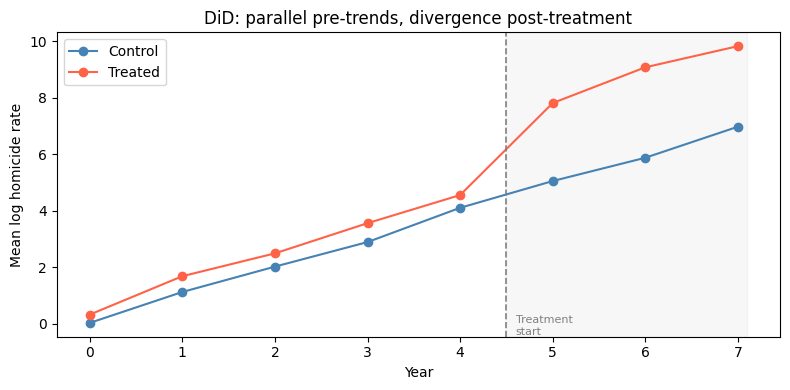

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 4))

for group, label, color in [(0, "Control", "steelblue"), (1, "Treated", "tomato")]:
    means = df_did[df_did["ever_treated"] == group].groupby("year")["l_homicide"].mean()
    ax.plot(means.index, means.values, marker="o", label=label, color=color)

ax.axvline(treatment_year - 0.5, color="gray", linestyle="--", linewidth=1.2)
ax.axvspan(treatment_year - 0.5, df_did["year"].max() + 0.1, alpha=0.06, color="gray")
ax.text(treatment_year - 0.4, ax.get_ylim()[0], "Treatment\nstart", fontsize=8, color="gray", va="bottom")
ax.set_xlabel("Year")
ax.set_ylabel("Mean log homicide rate")
ax.set_title("DiD: parallel pre-trends, divergence post-treatment")
ax.legend()
plt.tight_layout()
plt.show()

### Frontdoor Adjustment

The frontdoor criterion (Pearl 1995) provides identification when there is an unmeasured confounder between treatment T and outcome Y, but all causal paths from T to Y pass through an observed mediator M. In the canonical example, smoking (T) causes tar deposits in the lungs (M), which causes lung cancer (Y); genetic predisposition (U) confounds both smoking and cancer but does not affect tar separately from smoking.

<div style="text-align:center">
  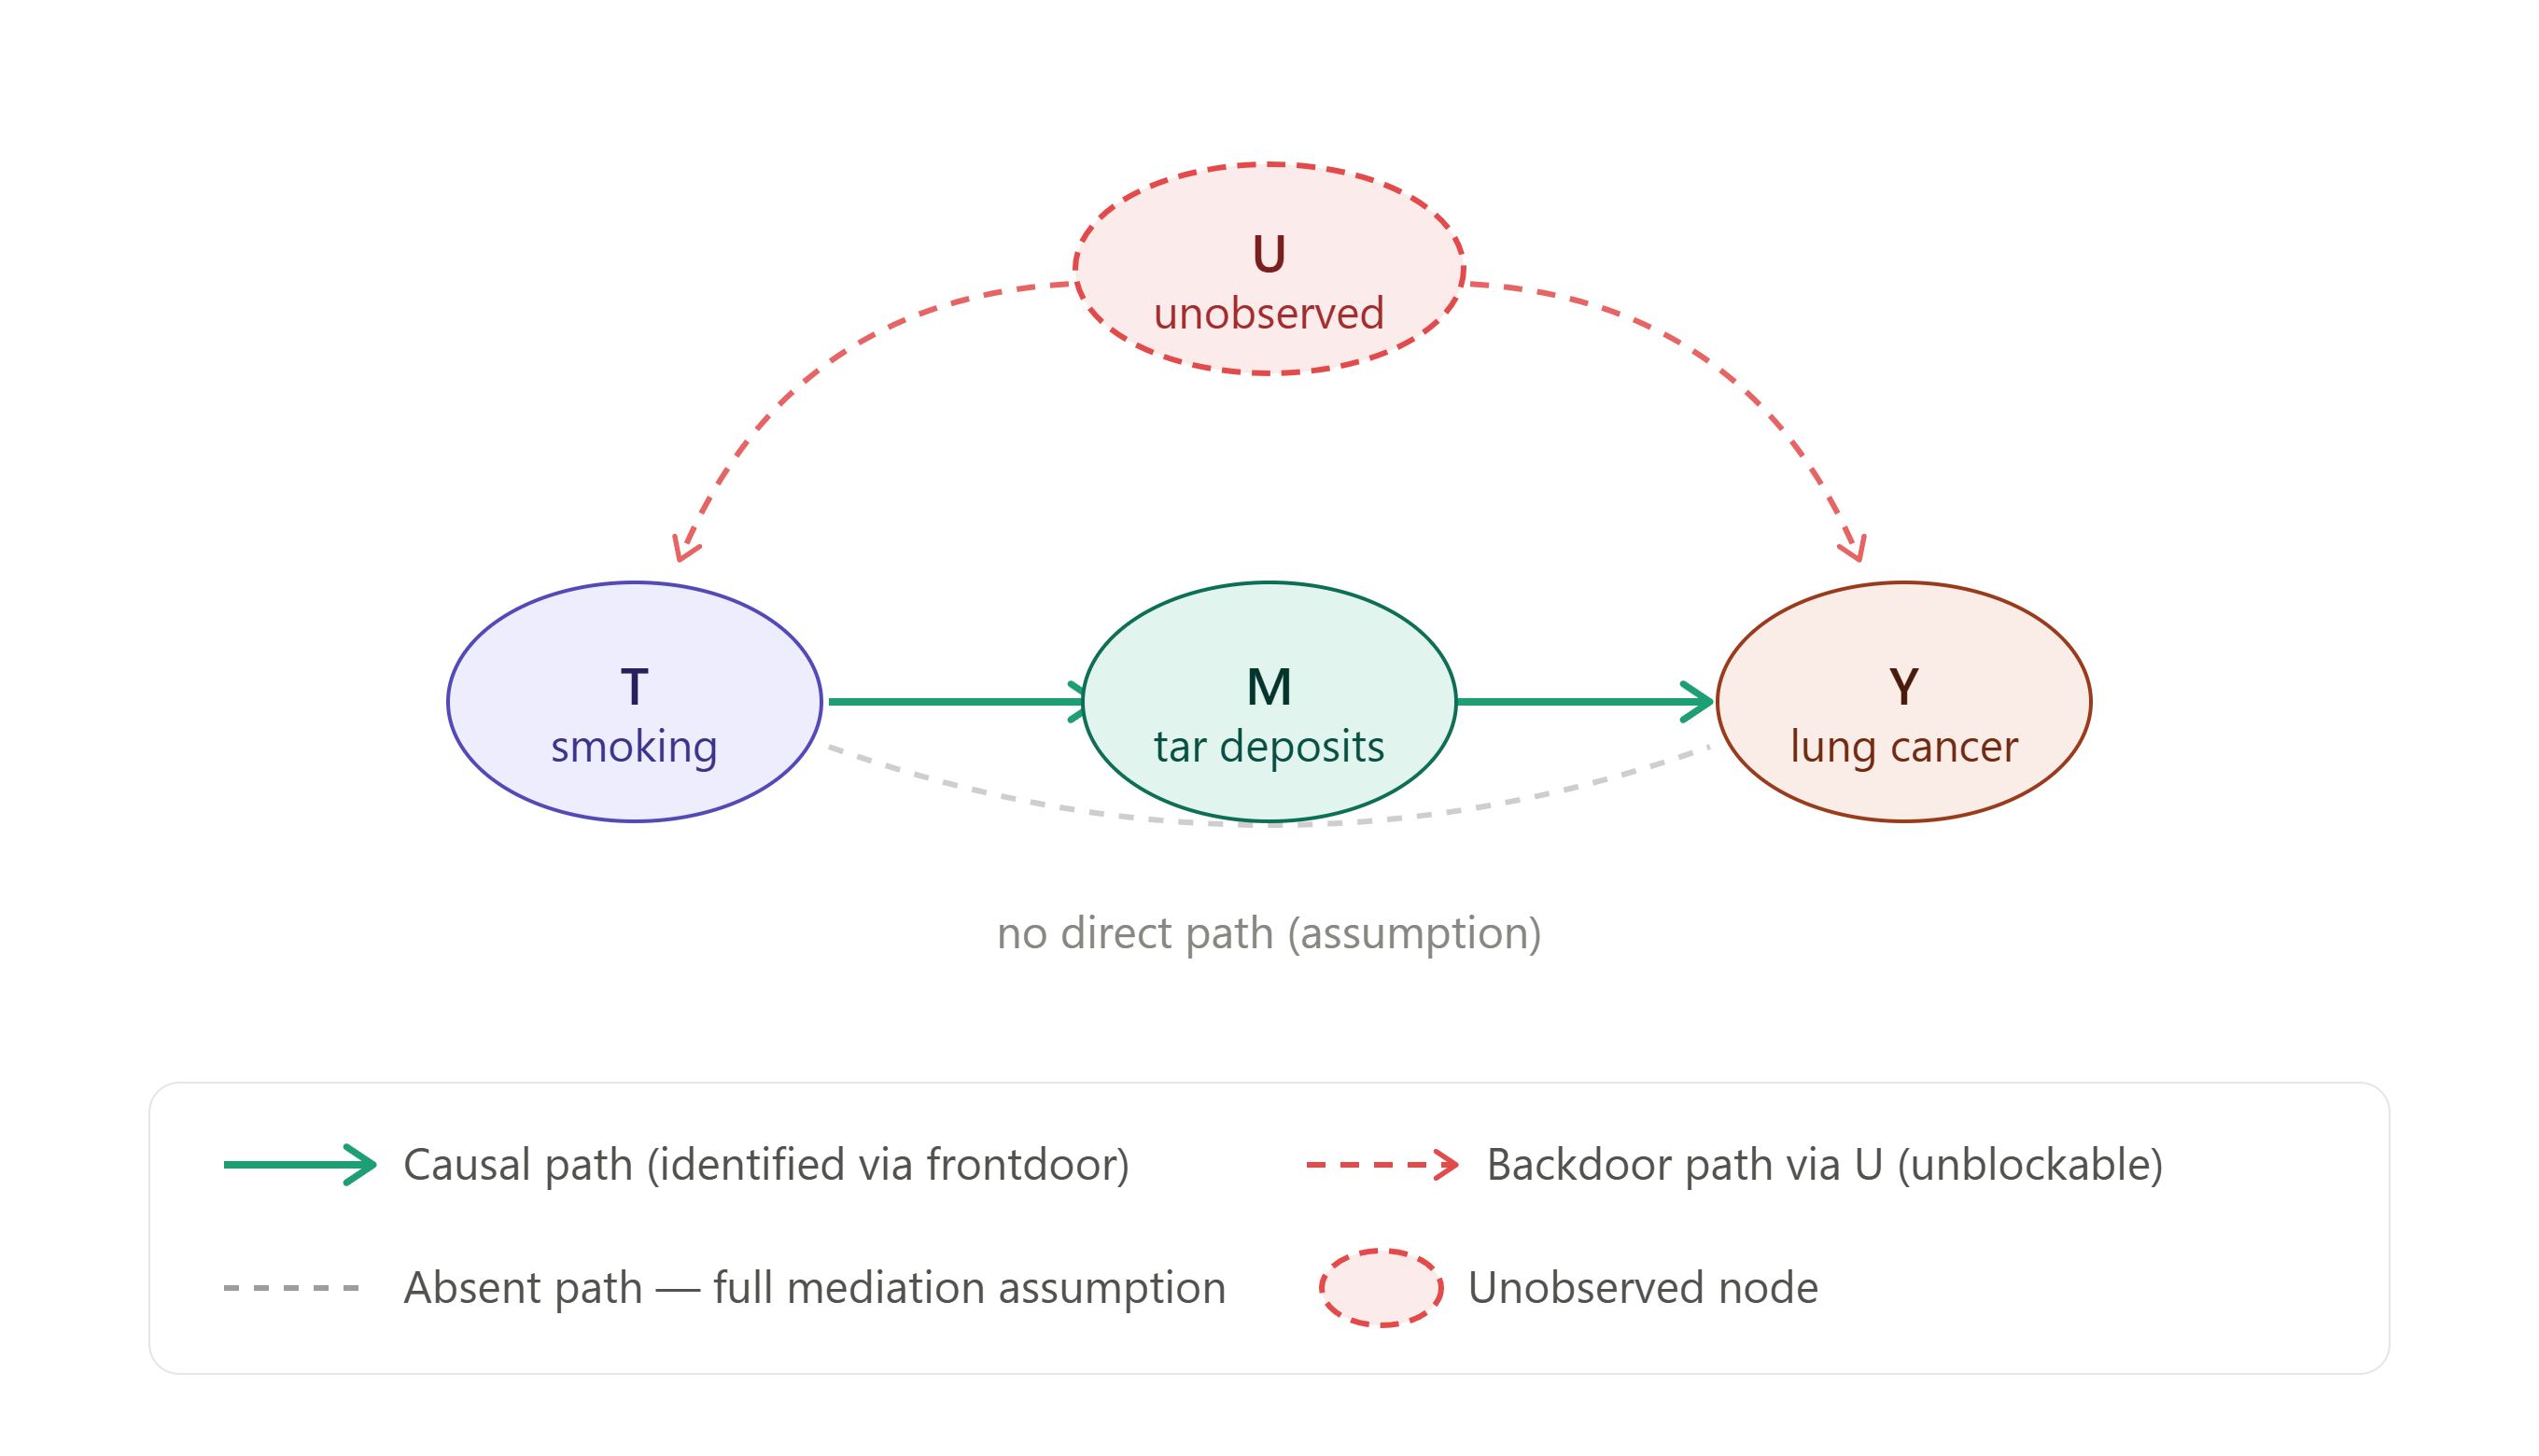
</div>

Under this design, the causal effect of T on Y can be identified using the product of two regressions: T→M (unconfounded, conditioned on nothing) and M→Y (conditioned on T, which blocks the back-door path from U through T).

This is elegant, but the assumptions are considerably stricter than standard backdoor adjustment:

| Assumption | What it means | Testable? |
|---|---|---|
| **Full mediation** | All causal effect of T on Y goes through M — no direct T→Y path | ❌ LLM reasoning |
| **No T–M confounding** | No unmeasured variable confounds T and M | ❌ LLM reasoning |
| **T blocks M→Y confounding** | Conditioning on T blocks all back-door paths between M and Y | ❌ LLM reasoning |
| **Positivity** | Every combination of (T=t, M=m) is observed in the data | ✅ Statistical check on cell counts |

Notice that three of the four assumptions require LLM reasoning, and the smoking/tar/cancer example below shows that the LLM correctly identifies violations arising from unobserved genetic confounders. The positivity check is the only one that can be verified from data, and it catches a common failure mode: if some (treatment, mediator) combinations never occur, the frontdoor formula is undefined for those cells.

In [28]:
from cais.methods.pre_model_assumption_utils import (
    check_frontdoor_full_mediation, check_frontdoor_no_TM_confounding,
    check_frontdoor_T_blocks_MY, check_frontdoor_positivity,
)

In [29]:
np.random.seed(10)
n_fd = 400
T_fd = np.random.binomial(1, 0.4, n_fd)
M_fd = np.random.binomial(1, 0.3 + 0.5 * T_fd)
df_fd = pd.DataFrame({"T": T_fd, "M": M_fd, "Y": M_fd * 0.6 + np.random.normal(0, 0.3, n_fd)})

frontdoor_description = (
    "Observational study: effect of smoking (T) on lung cancer (Y). "
    "Tar deposits in lungs (M) are the mediator. "
    "There may be unobserved genetic confounders affecting both T and Y."
)
frontdoor_variables = {
    "treatment": "smoking (T)", "mediator": "tar deposits (M)",
    "outcome": "lung cancer (Y)", "potential_confounders": "genetic predisposition (unobserved)",
}

vars_fd = AssumptionVariables(
    df=df_fd, treatment="T", outcome="Y", mediator="M",
    dataset_description=frontdoor_description, variables_summary=frontdoor_variables,
)

In [30]:
result_full_mediation = check_frontdoor_full_mediation(vars_fd, llm=llm)
print("check_frontdoor_full_mediation:", result_full_mediation)

check_frontdoor_full_mediation: passed=False reasoning='The assumption of full mediation is not plausibly satisfied because the presence of unobserved genetic confounders suggests that there may be a direct effect of smoking (T) on lung cancer (Y) that is not captured by tar deposits (M). These genetic factors could influence both the likelihood of smoking and the risk of developing lung cancer, indicating that the relationship between T and Y is not solely mediated by M. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Full mediation'}


In [31]:
result_no_tm_conf = check_frontdoor_no_TM_confounding(vars_fd, llm=llm)
print("check_frontdoor_no_TM_confounding:", result_no_tm_conf)

check_frontdoor_no_TM_confounding: passed=False reasoning='The assumption of no T-M confounding is not plausibly satisfied because the dataset description indicates the presence of unobserved genetic confounders that may affect both smoking (T) and tar deposits (M). This suggests that there could be unmeasured factors influencing the relationship between the treatment and the mediator, violating the assumption. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'No T-M confounding'}


In [32]:
result_t_blocks = check_frontdoor_T_blocks_MY(vars_fd, llm=llm)
print("check_frontdoor_T_blocks_MY:", result_t_blocks)

check_frontdoor_T_blocks_MY: passed=False reasoning='The assumption that T blocks M->Y confounding is not plausibly satisfied because there are unobserved genetic confounders that may affect both smoking (T) and lung cancer (Y). These unobserved confounders can create back-door paths between the mediator (M) and the outcome (Y), which conditioning on T alone cannot remove. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'T blocks M->Y confounding'}


In [33]:
result_fd_positivity = check_frontdoor_positivity(vars_fd, min_count=5)
print("Normal case:", result_fd_positivity)

Normal case: passed=True reasoning='4/4 (treatment, mediator) combinations observed. 0 empty, 0 sparse (< 5 obs). Positivity satisfied.' details={'total_combos': 4, 'observed_combos': 4, 'empty': 0, 'sparse': 0, 'min_count': 5}


In [34]:
df_fd_bad = df_fd[~((df_fd["T"] == 1) & (df_fd["M"] == 0))].copy()
vars_fd_bad = AssumptionVariables(df=df_fd_bad, treatment="T", outcome="Y", mediator="M")
result_fd_positivity_bad = check_frontdoor_positivity(vars_fd_bad, min_count=5)
print("Violation case:", result_fd_positivity_bad)

Violation case: passed=False reasoning='3/4 (treatment, mediator) combinations observed. 1 empty, 0 sparse (< 5 obs). Some combinations are empty or near-empty — frontdoor formula may be undefined.' details={'total_combos': 4, 'observed_combos': 3, 'empty': 1, 'sparse': 0, 'min_count': 5}


### Regression Discontinuity Design (RDD)

RDD exploits a rule-based threshold in a continuous *running variable* to create as-good-as-random treatment assignment near the cutoff. The logic: units just above and just below the threshold are essentially identical in expectation, so any discontinuous jump in the outcome at the cutoff can be attributed to the treatment rather than selection.

The design is compelling because the identifying assumption, **continuity of potential outcomes**, is considerably more credible than the unconfoundedness assumption required for propensity-score methods. It does not require measuring all confounders; it only requires that nothing else jumps discontinuously at the cutoff.

However, this credibility is contingent on two additional assumptions that must be verified:

| Assumption | What it means | How it is checked |
|---|---|---|
| **No manipulation** | Units cannot precisely sort themselves to one side of the cutoff | Local density balance: binomial test comparing observation counts just above and below the cutoff within a bandwidth |
| **Covariate continuity** | Pre-determined covariates are continuous at the cutoff (no selection on observables) | t-tests comparing covariate means just above and below the threshold |
| **Continuity of potential outcomes** | The underlying outcome (absent treatment) evolves smoothly through the cutoff | LLM reasoning about whether any other rule or behavior changes at the threshold |

**Manipulation** is the central threat to RDD validity. If units can control their running variable precisely enough to land on a desired side of the cutoff (e.g., professors grading strategically to keep students above a scholarship threshold), the local randomisation argument breaks down. The no-manipulation check used here is a binomial approximation: it counts observations on each side of the cutoff within a local bandwidth and tests whether the split is consistent with chance (binomial(n, 0.5)).

> Note that this is a simplified version of the McCrary (2008) density test, the latter fits local linear regressions to the full density histogram and is more robust for larger datasets or asymmetric running variable distributions.

The DUI example below uses BAC as the running variable. Because individuals cannot control their precise BAC during a breathalyzer test, manipulation is implausible by design, and the density balance test confirms this.

In [35]:
from cais.methods.pre_model_assumption_utils import (
    check_rdd_no_manipulation, check_rdd_covariate_continuity,
    check_rdd_continuity_potential_outcomes,
)

In [36]:
np.random.seed(11)
n_rdd = 3000
# Running variable symmetric around cutoff 0.08 → no natural density imbalance
bac1 = np.random.uniform(0.00, 0.16, n_rdd)
treated_rdd = (bac1 >= 0.08).astype(int)
df_rdd = pd.DataFrame({
    "bac1":       bac1,
    "male":       np.random.binomial(1, 0.7, n_rdd),
    "white":      np.random.binomial(1, 0.6, n_rdd),
    "acc":        np.random.binomial(1, 0.1, n_rdd),
    "aged":       np.random.normal(30, 8, n_rdd),
    "recidivism": 0.3 - 0.1 * treated_rdd + np.random.normal(0, 0.2, n_rdd),
})

rdd_description = (
    "Synthetic DUI records. Running variable: BAC (blood alcohol content). "
    "Cutoff: 0.08. Treatment: DUI sanction. Outcome: recidivism (future DUI). "
    "Individuals cannot precisely control their BAC during a breathalyzer test."
)

print(f"Shape: {df_rdd.shape}  |  BAC range: {df_rdd['bac1'].min():.3f}-{df_rdd['bac1'].max():.3f}")
print(f"Treated (BAC >= 0.08): {treated_rdd.sum()} / {n_rdd}")

Shape: (3000, 6)  |  BAC range: 0.000-0.160
Treated (BAC >= 0.08): 1510 / 3000


In [37]:
vars_rdd = AssumptionVariables(
    df=df_rdd, running_variable="bac1", cutoff=0.08,
    covariates=["male", "white", "acc", "aged"],
    dataset_description=rdd_description,
    variables_summary={"running_variable": "bac1", "cutoff": 0.08},
)

result_no_manip = check_rdd_no_manipulation(vars_rdd)
print("check_rdd_no_manipulation:", result_no_manip)

check_rdd_no_manipulation: passed=True reasoning="Density test around cutoff (0.08): 776 below, 735 above (p=0.3035). Note: This binomial test is a local approximation of density continuity and may be sensitive to the underlying distribution's slope. No evidence of manipulation." details={'n_below': 776, 'n_above': 735, 'p_value': np.float64(0.3034643379037195), 'bandwidth': np.float64(0.039891225450833664), 'test_type': 'binomial_density_approximation'}


In [38]:
result_cov_cont = check_rdd_covariate_continuity(vars_rdd)
print("check_rdd_covariate_continuity:", result_cov_cont)

check_rdd_covariate_continuity: passed=True reasoning='Covariate continuity at cutoff (0.08) on 4 covariates. All continuous.' details={'covariate_tests': {'male': {'t_stat': -0.5429206465045152, 'p_value': 0.5873833313092989}, 'white': {'t_stat': -1.889775522795812, 'p_value': 0.059262806593870364}, 'acc': {'t_stat': 1.1672998227154388, 'p_value': 0.24354663803402246}, 'aged': {'t_stat': 1.1697732250928017, 'p_value': 0.24256191864796328}}, 'discontinuous': [], 'bandwidth': np.float64(0.015956490180333467)}


In [39]:
result_po_continuity = check_rdd_continuity_potential_outcomes(vars_rdd, llm=llm)
print("check_rdd_continuity_potential_outcomes:", result_po_continuity)

check_rdd_continuity_potential_outcomes: passed=True reasoning='The assumption of continuity of potential outcomes at the cutoff is plausibly satisfied because individuals cannot precisely control their BAC during a breathalyzer test, suggesting that those just above and just below the 0.08 threshold are likely to be similar in unobserved characteristics that affect recidivism. Additionally, the nature of BAC as a continuous variable implies that small changes around the cutoff should not lead to large differences in potential outcomes. Note: this assessment relies on LLM reasoning and is sensitive to the quality and completeness of the dataset description provided.' details={'assumption': 'Continuity of potential outcomes at the cutoff'}


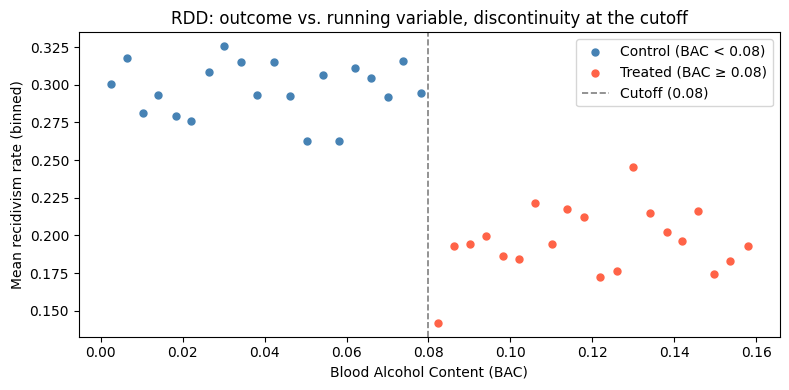

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))

# Bin the running variable and compute mean outcome per bin
bins = np.linspace(df_rdd["bac1"].min(), df_rdd["bac1"].max(), 41)
df_rdd["_bin"] = pd.cut(df_rdd["bac1"], bins=bins)
binned = (
    df_rdd.groupby("_bin", observed=True)
    .agg(bac_mid=("bac1", "mean"), rec_mean=("recidivism", "mean"))
    .dropna()
)
df_rdd.drop(columns="_bin", inplace=True)

below = binned[binned["bac_mid"] < 0.08]
above = binned[binned["bac_mid"] >= 0.08]

ax.scatter(below["bac_mid"], below["rec_mean"], color="steelblue", s=25, label="Control (BAC < 0.08)")
ax.scatter(above["bac_mid"], above["rec_mean"], color="tomato",    s=25, label="Treated (BAC ≥ 0.08)")
ax.axvline(0.08, color="gray", linestyle="--", linewidth=1.2, label="Cutoff (0.08)")
ax.set_xlabel("Blood Alcohol Content (BAC)")
ax.set_ylabel("Mean recidivism rate (binned)")
ax.set_title("RDD: outcome vs. running variable, discontinuity at the cutoff")
ax.legend()
plt.tight_layout()
plt.show()

## Post-modeling assumption checks
---

Pre-modeling checks answer the question: *"Is this causal method appropriate for this data?"* Post-modeling checks answer a different question: *"Is the fitted model itself well-specified and valid?"*

These checks run after the causal estimator has been fitted and assess the quality of the estimation step itself. A correctly chosen method with a misspecified model still produces a biased estimate. Post-modeling checks make this visible.

CAIS implements three post-modeling checks:

| Check | Method | What a failure means                                                                                                      |
|---|---|---------------------------------------------------------------------------------------------------------------------------|
| **GPS model specification** | Shapiro-Wilk test on residuals of the generalized propensity score model (continuous treatment) | The GPS model functional form is wrong, the treatment assignment mechanism is not well approximated by the fitted model   |
| **Balance after matching** | SMD on covariates in the matched sample | The matching algorithm failed to adequately balance treated and control units, the matched comparison is still confounded |
| **Balance after weighting** | Weighted SMD on covariates | IPW weights fail to achieve balance, the propensity score model is likely misspecified                                    |
| **IV overidentification** | Sargan-Hansen J-test (requires ≥2 instruments) | At least one instrument is correlated with the error term, not all instruments are valid                                  |

The balance checks after matching and weighting are particularly important: a propensity score model that achieves high predictive accuracy (AUC ≈ 0.9) does not guarantee covariate balance. The two are measuring different things. Only a direct balance check on the matched or weighted sample can confirm that the comparison groups are exchangeable on observed covariates; which is the actual requirement for unbiased estimation.

#### Generalized Propensity Score

In [41]:
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from cais.methods.post_model_assumption_utils import (
    check_gps_specification,
    check_balance_after_matching,
    check_balance_after_weighting,
    check_iv_overidentification,
)

Let's compute Generalized Propensity Scores on synthetic continuous-treatment data and verify residual normality of the GPS model.

In [42]:
np.random.seed(99)
n_gps = 300
X1_gps = np.random.normal(0, 1, n_gps)
X2_gps = np.random.binomial(1, 0.5, n_gps)
T_gps  = 5 + 1.5 * X1_gps - 0.5 * X2_gps + np.random.normal(0, 2, n_gps)
Y_gps  = 2 * T_gps + X1_gps + np.random.normal(0, 1, n_gps)

df_gps = pd.DataFrame({"T": T_gps, "Y": Y_gps, "X1": X1_gps, "X2": X2_gps})
vars_gps = AssumptionVariables(df=df_gps, treatment="T", outcome="Y", covariates=["X1", "X2"])

print(f"Shape: {df_gps.shape}  |  T range: {T_gps.min():.2f}–{T_gps.max():.2f}")

Shape: (300, 4)  |  T range: -4.31–14.40


In [43]:
X = sm.add_constant(df_gps[["X1", "X2"]])
gps_model = sm.OLS(df_gps["T"], X).fit()
residuals = gps_model.resid.values
print(f"Residuals: n={len(residuals)}, mean={residuals.mean():.4f}, std={residuals.std():.4f}")

Residuals: n=300, mean=0.0000, std=2.0418


In [44]:
result_gps_spec = check_gps_specification(residuals)
print("check_gps_specification (synthetic):", result_gps_spec)

check_gps_specification (synthetic): passed=True reasoning='Shapiro-Wilk on GPS model residuals: W=0.996, p=0.7223. Residuals consistent with normality.' details={'shapiro_w': 0.9963487030343325, 'p_value': 0.7222526515436741}


In [45]:
residuals_normal = np.random.default_rng(15).normal(0, 1, 300)
result_gps_normal = check_gps_specification(residuals_normal)
print("check_gps_specification (normal parfait):", result_gps_normal)

check_gps_specification (normal parfait): passed=True reasoning='Shapiro-Wilk on GPS model residuals: W=0.994, p=0.3064. Residuals consistent with normality.' details={'shapiro_w': 0.994176994018983, 'p_value': 0.30641476530536893}


In [46]:
residuals_bad = np.concatenate([np.random.exponential(2, 200), -np.random.exponential(2, 100)])
result_gps_bad = check_gps_specification(residuals_bad)
print("check_gps_specification (non-normal):", result_gps_bad)

check_gps_specification (non-normal): passed=False reasoning='Shapiro-Wilk on GPS model residuals: W=0.909, p=0.0000. Significant departure from normality — consider re-specifying the GPS model.' details={'shapiro_w': 0.9093592043581701, 'p_value': 1.8303063666286257e-12}


#### Balance checks after adjustment (matching and IPW)

Once a propensity score model is fitted, two common adjustment strategies are available: **matching** and **inverse probability weighting (IPW)**. Both aim to make the treated and control groups comparable on observed covariates; but they do so differently, and both require post-adjustment balance verification.

A high propensity-score model accuracy (AUC ≈ 0.9) does not guarantee covariate balance. The two metrics measure different things: the model can predict treatment well while still leaving substantial imbalance in the covariate distributions of treated vs. control. Only a direct |SMD| check on the adjusted sample confirms that the comparison groups are exchangeable; which is the actual requirement for unbiased estimation.

In [47]:
np.random.seed(20)
n_m = 400
age_m    = np.random.normal(40, 10, n_m)
income_m = np.random.normal(50_000, 15_000, n_m)
ps_conf  = 1 / (1 + np.exp(-(-1.5 + 0.04 * age_m + 0.00001 * income_m)))
treat_m  = (np.random.uniform(size=n_m) < ps_conf).astype(int)
y_m      = 3 * treat_m + 0.02 * age_m + np.random.normal(0, 1, n_m)
re74_m   = np.random.normal(15_000, 5_000, n_m)
re75_m   = re74_m + np.random.normal(500, 1_000, n_m)

df_m = pd.DataFrame({
    "treat": treat_m, "outcome": y_m,
    "age": age_m, "income": income_m, "re74": re74_m, "re75": re75_m,
})
covariates_m = ["age", "income", "re74", "re75"]
vars_m = AssumptionVariables(df=df_m, treatment="treat", outcome="outcome", covariates=covariates_m)

print(f"Dataset: {len(df_m)} obs, treated={treat_m.sum()}, controls={n_m - treat_m.sum()}")

Dataset: 400 obs, treated=253, controls=147


**Nearest-neighbour matching**

Matching pairs each treated unit with the control unit(s) most similar to it — typically on propensity score or on covariates directly. The matched sample then contains only units that have a close counterpart in the other group, discarding unmatched controls.

The key post-matching question is: did the algorithm actually achieve balance? Matching on propensity score is not guaranteed to balance all individual covariates, especially if the PS model is misspecified or if the common support is limited. `check_balance_after_matching` computes |SMD| for each covariate in the matched sample and flags any that remain above the 0.1 threshold. A failed check here means the matched comparison is still confounded on those covariates, and the analyst should consider caliper matching, exact matching on key variables, or re-specifying the PS model.

In [48]:
ps_m = LogisticRegression(max_iter=1000).fit(df_m[covariates_m], treat_m).predict_proba(df_m[covariates_m])[:, 1]
ps_m = np.clip(ps_m, 0.01, 0.99)

treated_idx_m = df_m[treat_m == 1].index
control_idx_m = df_m[treat_m == 0].index

nn = NearestNeighbors(n_neighbors=1)
nn.fit(ps_m[treat_m == 0].reshape(-1, 1))
_, indices = nn.kneighbors(ps_m[treat_m == 1].reshape(-1, 1))
matched_ctrl_idx = control_idx_m[indices.flatten()]

df_matched_m = pd.concat([df_m.loc[treated_idx_m], df_m.loc[matched_ctrl_idx]])
print(f"Matched sample: {len(df_matched_m)} rows ({treat_m.sum()} treated + {treat_m.sum()} matched controls)")

Matched sample: 506 rows (253 treated + 253 matched controls)


In [49]:
result_balance_match = check_balance_after_matching(vars_m, df_matched=df_matched_m)
print("check_balance_after_matching:", result_balance_match)

check_balance_after_matching: passed=False reasoning="Matched sample balance on 4 covariates (|SMD| < 0.1). Still imbalanced: ['income']." details={'smds': {'age': np.float64(0.00760926434039024), 'income': np.float64(-0.12082640434573834), 're74': np.float64(-0.013659121516863009), 're75': np.float64(-0.006487062550468167)}, 'threshold': 0.1, 'imbalanced': {'income': np.float64(-0.12082640434573834)}}


**Inverse probability weighting (IPW)**

Rather than discarding unmatched units, IPW reweights the entire sample to create a pseudo-population in which treatment is independent of observed covariates. Each treated unit receives weight `1/PS` and each control unit receives weight `1/(1-PS)`, effectively up-weighting units whose treatment assignment was unlikely given their covariates.

IPW targets the **ATE** (average treatment effect over the full population), whereas matching typically targets the **ATT** (average treatment effect on the treated). This distinction matters when treated and control populations differ substantially.

`check_balance_after_weighting` computes weighted SMDs. The covariate means are compared under the IPW-weighted distributions rather than the raw sample. A failed check indicates that the propensity score model is misspecified: the weights are not sufficient to equate the two groups. Common remedies include adding interaction terms or higher-order terms to the PS model, or trimming extreme weights that destabilise the estimator.

The love plot below summarises all three balance states (raw, matched, weighted) side by side for each covariate.

In [50]:
weights_m = np.where(treat_m == 1, 1 / ps_m, 1 / (1 - ps_m))
result_balance_ipw = check_balance_after_weighting(vars_m, weights=weights_m)
print("check_balance_after_weighting:", result_balance_ipw)

check_balance_after_weighting: passed=True reasoning='Weighted balance on 4 covariates (|SMD| < 0.1). All balanced after IPW.' details={'weighted_smds': {'age': 0.00910725596371094, 'income': -0.010057700163292667, 're74': -0.013605064222686354, 're75': -0.015450807253460288}, 'threshold': 0.1, 'imbalanced': {}}


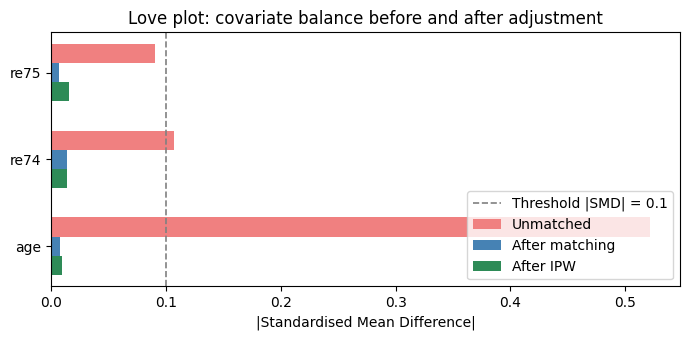

In [51]:
plot_covariates = ["age", "re74", "re75"]

def compute_smd(df, treatment, covariate):
    t = df[df[treatment] == 1][covariate]
    c = df[df[treatment] == 0][covariate]
    return (t.mean() - c.mean()) / np.sqrt((t.std() ** 2 + c.std() ** 2) / 2)

smds_raw      = {c: compute_smd(df_m, "treat", c) for c in plot_covariates}
smds_matched  = result_balance_match.details["smds"]
smds_weighted = result_balance_ipw.details["weighted_smds"]

fig, ax = plt.subplots(figsize=(7, 3.5))

y = np.arange(len(plot_covariates))
h = 0.22

ax.barh(y + h, [abs(smds_raw[c])      for c in plot_covariates], h, label="Unmatched",     color="lightcoral")
ax.barh(y,     [abs(smds_matched[c])  for c in plot_covariates], h, label="After matching", color="steelblue")
ax.barh(y - h, [abs(smds_weighted[c]) for c in plot_covariates], h, label="After IPW",      color="seagreen")

ax.axvline(0.1, color="gray", linestyle="--", linewidth=1.2, label="Threshold |SMD| = 0.1")
ax.set_yticks(y)
ax.set_yticklabels(plot_covariates)
ax.set_xlabel("|Standardised Mean Difference|")
ax.set_title("Love plot: covariate balance before and after adjustment")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### IV overidentification test (post-estimation)

In [52]:
# Single instrument → test not applicable (need more instruments than endogenous regressors)
vars_iv_single = AssumptionVariables(
    df=df_iv, treatment="educ", outcome="lwage",
    instruments=["nearc4"], covariates=iv_covariates,
)
result_overid_single = check_iv_overidentification(vars_iv_single, sm_results=None)
print("Single instrument:", result_overid_single)

Single instrument: passed=None reasoning='Test not applicable (Need more instruments than endogenous regressors)' details={}


With two instruments, the Sargan-Hansen test can be performed. Note: `smsa` is added here as a second instrument for illustration only, in practice it would not satisfy the exclusion restriction.

In [53]:
from statsmodels.sandbox.regression.gmm import IV2SLS

instruments_2   = ["nearc4", "smsa"]
covariates_iv2  = ["black", "south", "married", "exper"]

endog            = df_iv["lwage"]
exog             = sm.add_constant(df_iv[["educ"] + covariates_iv2])
instrument_matrix = sm.add_constant(df_iv[instruments_2 + covariates_iv2])

iv2sls = IV2SLS(endog, exog, instrument_matrix).fit()

In [54]:
vars_iv2 = AssumptionVariables(
    df=df_iv, treatment="educ", outcome="lwage",
    instruments=instruments_2, covariates=covariates_iv2,
)
result_overid_two = check_iv_overidentification(vars_iv2, sm_results=iv2sls)
print("Two instruments (Sargan-Hansen):", result_overid_two)

Two instruments (Sargan-Hansen): passed=True reasoning='Sargan-Hansen test: statistic=0.59, p=0.4421. Instruments appear valid (not correlated with errors).' details={'statistic': 0.5908051774658363, 'p_value': 0.44210793039184293, 'status': 'Test successful'}


## Summary: the case for systematic assumption checking
---

Causal inference is harder than prediction. Predictive models have a clear evaluation signal; held-out accuracy. Causal estimators do not: the counterfactual is never observed, so there is no ground truth to compare against after the fact. This means **the credibility of a causal estimate rests entirely on the credibility of the assumptions** that justify it.

The checks demonstrated in this notebook address this directly. Rather than treating assumption validation as an afterthought, CAIS makes it a reproducible step in every analysis:

- **Statistical checks** (covariate balance, instrument strength, density continuity, residual normality) provide objective, quantitative evidence against the data.

- **LLM-based checks** handle the assumptions that are fundamentally untestable from data alone. Instead of leaving these to implicit expert judgment, which is invisible, unreproducible, and often skipped, CAIS externalises the reasoning. The LLM articulates *why* an assumption is or is not plausible given the study design, and this reasoning is returned as structured output that can be audited, challenged, and improved.

- **Post-modeling checks** close the loop by verifying that the estimation step itself did not introduce new problems, that matching achieved balance, that weights did not fail to equalise groups, that IV instruments are mutually consistent.

Together, these checks transform assumption auditing from a subjective step done once (if at all) into a transparent, automated, and repeatable component of the causal analysis pipeline. This is what distinguishes principled causal analysis from simply running an estimator and reporting the output.

### A note on partial failures

Not all failed checks are equally damaging. A `passed=False` result is a signal, not a veto. The analyst must interpret each failure in context:
- A failed parallel-trends test with p = 0.04 in a dataset with many pre-treatment periods and a large number of units may reflect low statistical power, not a true violation.
- A failed balance check post-matching may be resolved by re-specifying the propensity score model or switching to entropy balancing.
- An LLM verdict of `passed=False` on the exclusion restriction with a well-argued mechanism still warrants human review.

The value of CAIS is not that it makes these decisions automatically: it is that it makes the relevant evidence visible, structured, and reproducible, so that the analyst's judgment is informed rather than blind.